In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import os 
import numpy as np

cwd = os.getcwd()
sep = os.sep
cwd

'/home/ugo/Scrivania/Transthyretin/ProteinContactNetworks'

In [2]:
adj_dir = cwd + sep + "Outputs" + sep + "Adj"
louvain_dir = cwd + sep + "Outputs" + sep + "louvain" + sep + "Communities"

mutant_name = "wt-tetramer"
adj_file = adj_dir + sep + mutant_name + "_adj_mat_4.0_8.0.txt"
louvain_file = louvain_dir + sep + mutant_name + "_Communities_louvain_ncoms11.txt"

In [3]:
a = np.loadtxt(adj_file).astype(np.int64)
a.shape

(508, 508)

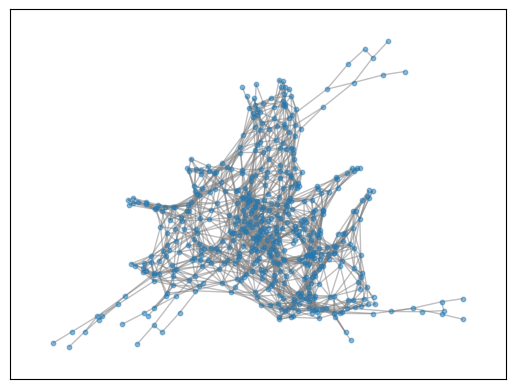

In [4]:
G = nx.from_numpy_array(a, create_using=nx.Graph)
G = nx.relabel_nodes(G, {i: str(i) for i in range(len(G.nodes))})
nx.draw_networkx(G, with_labels=False, node_size=10, edge_color='gray', alpha=0.5)

In [5]:
import ast
louvain_dict = ast.literal_eval(open(louvain_file, 'r').read())
rename_labels = {str(i): residue for i, residue in enumerate(louvain_dict.keys())}
nx.relabel_nodes(G, rename_labels, copy=False)
G.nodes(data=True)

NodeDataView({'GLY1 A': {}, 'PRO2 A': {}, 'THR3 A': {}, 'GLY4 A': {}, 'THR5 A': {}, 'GLY6 A': {}, 'GLU7 A': {}, 'SER8 A': {}, 'LYS9 A': {}, 'CYS10 A': {}, 'PRO11 A': {}, 'LEU12 A': {}, 'MET13 A': {}, 'VAL14 A': {}, 'LYS15 A': {}, 'VAL16 A': {}, 'LEU17 A': {}, 'ASP18 A': {}, 'ALA19 A': {}, 'VAL20 A': {}, 'ARG21 A': {}, 'GLY22 A': {}, 'SER23 A': {}, 'PRO24 A': {}, 'ALA25 A': {}, 'ILE26 A': {}, 'ASN27 A': {}, 'VAL28 A': {}, 'ALA29 A': {}, 'VAL30 A': {}, 'HIS31 A': {}, 'VAL32 A': {}, 'PHE33 A': {}, 'ARG34 A': {}, 'LYS35 A': {}, 'ALA36 A': {}, 'ALA37 A': {}, 'ASP38 A': {}, 'ASP39 A': {}, 'THR40 A': {}, 'TRP41 A': {}, 'GLU42 A': {}, 'PRO43 A': {}, 'PHE44 A': {}, 'ALA45 A': {}, 'SER46 A': {}, 'GLY47 A': {}, 'LYS48 A': {}, 'THR49 A': {}, 'SER50 A': {}, 'GLU51 A': {}, 'SER52 A': {}, 'GLY53 A': {}, 'GLU54 A': {}, 'LEU55 A': {}, 'HIS56 A': {}, 'GLY57 A': {}, 'LEU58 A': {}, 'THR59 A': {}, 'THR60 A': {}, 'GLU61 A': {}, 'GLU62 A': {}, 'GLU63 A': {}, 'PHE64 A': {}, 'VAL65 A': {}, 'GLU66 A': {}, 'GLY6

In [6]:
nx.set_node_attributes(G, louvain_dict, 'community')
pos = nx.spring_layout(G, seed=42)
G.nodes(data=True)

NodeDataView({'GLY1 A': {'community': 5}, 'PRO2 A': {'community': 5}, 'THR3 A': {'community': 5}, 'GLY4 A': {'community': 5}, 'THR5 A': {'community': 5}, 'GLY6 A': {'community': 5}, 'GLU7 A': {'community': 5}, 'SER8 A': {'community': 5}, 'LYS9 A': {'community': 5}, 'CYS10 A': {'community': 5}, 'PRO11 A': {'community': 5}, 'LEU12 A': {'community': 5}, 'MET13 A': {'community': 5}, 'VAL14 A': {'community': 5}, 'LYS15 A': {'community': 5}, 'VAL16 A': {'community': 5}, 'LEU17 A': {'community': 5}, 'ASP18 A': {'community': 5}, 'ALA19 A': {'community': 2}, 'VAL20 A': {'community': 2}, 'ARG21 A': {'community': 2}, 'GLY22 A': {'community': 2}, 'SER23 A': {'community': 2}, 'PRO24 A': {'community': 5}, 'ALA25 A': {'community': 5}, 'ILE26 A': {'community': 5}, 'ASN27 A': {'community': 5}, 'VAL28 A': {'community': 5}, 'ALA29 A': {'community': 6}, 'VAL30 A': {'community': 6}, 'HIS31 A': {'community': 6}, 'VAL32 A': {'community': 6}, 'PHE33 A': {'community': 6}, 'ARG34 A': {'community': 6}, 'LYS35 A'

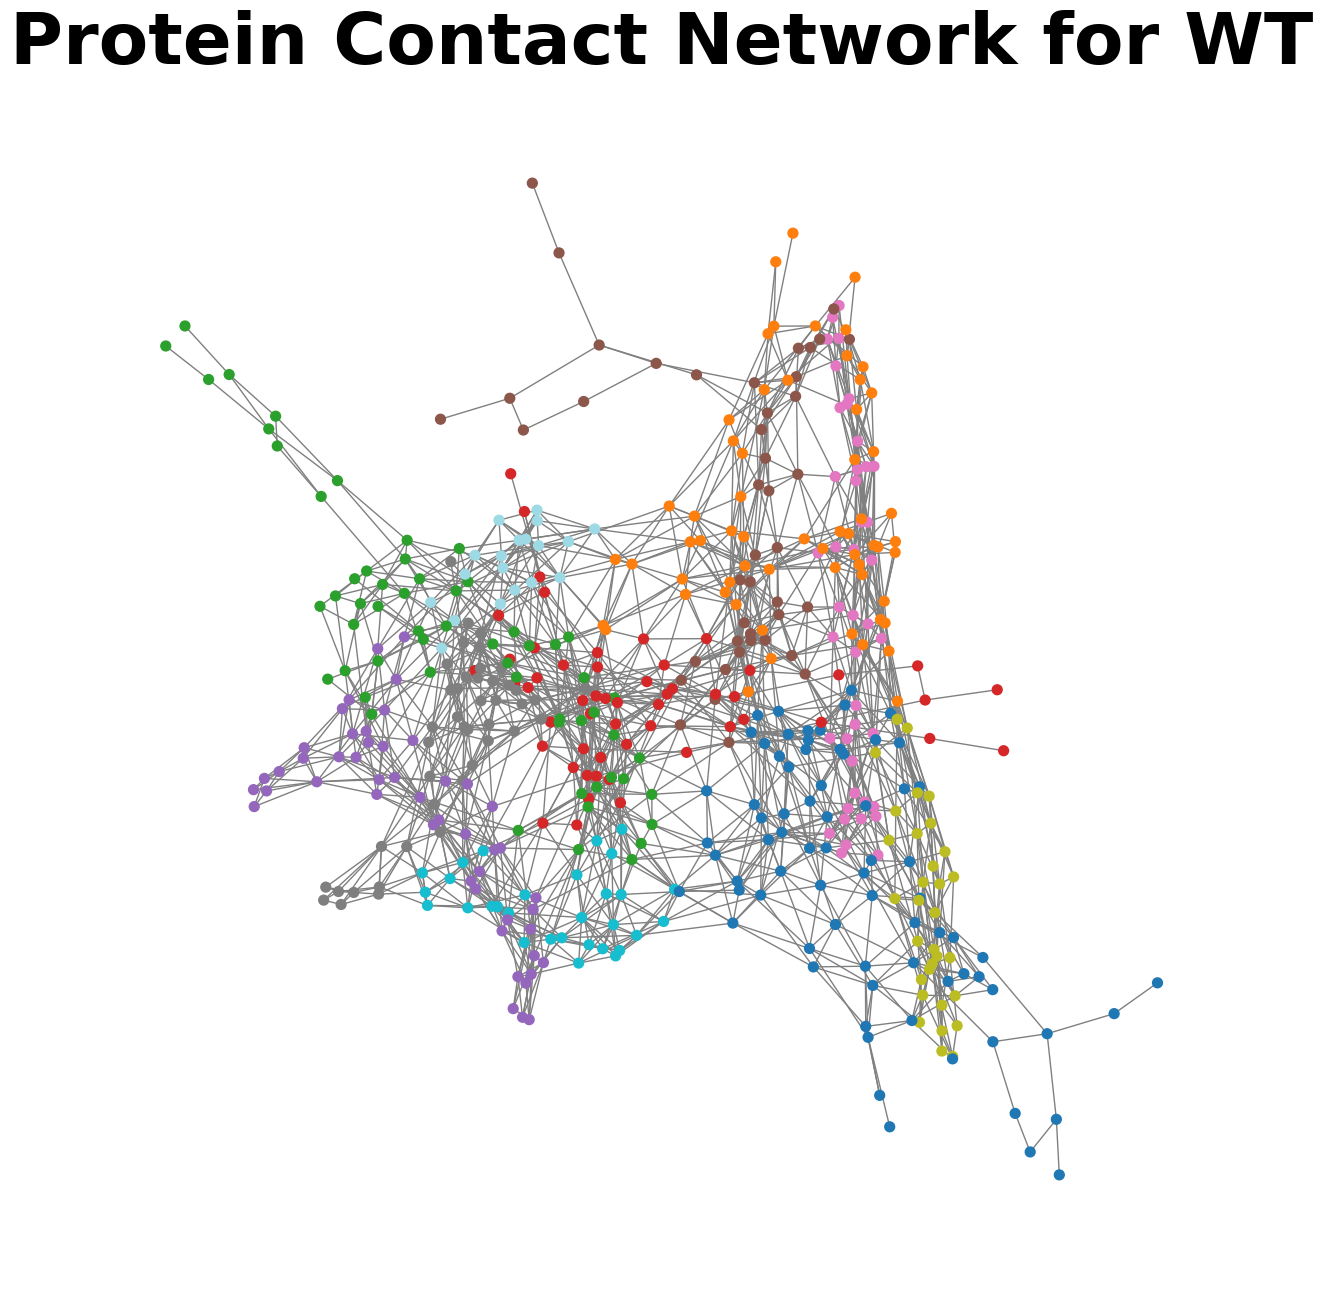

In [10]:
node_colors = [G.nodes[n]['community'] for n in G.nodes()]
fig = plt.figure(figsize=(12, 12))
nx.draw(G, pos, with_labels=False, cmap=plt.cm.tab20, node_size=50, font_size=8, node_color=node_colors, font_color='black', edge_color='gray')
mutant_name = mutant_name.split("-")[0]
plt.title(f"Protein Contact Network for {mutant_name.upper()}", fontsize=52, weight='bold')
plt.axis('off')
plt.show()  
# Save the figure
output_name = f"{mutant_name}-tetramer_louvain_pcn.png"
fig.savefig(output_name, dpi=600, bbox_inches='tight')